# Solução da Equação de Laplace com Geometria Curva e Condições de Contorno

Este notebook implementa a solução da equação de Laplace 2D com:
- Domínio com cantos arredondados (curvatura convexa)
- Ajustes locais nos pontos da borda curva com fatores $\alpha $ e $\beta$
- Condições de contorno:
  - Temperatura fixa nas faces superior e inferior
  - Fluxo de calor constante nas faces laterais
  - Bordas curvas adiabáticas

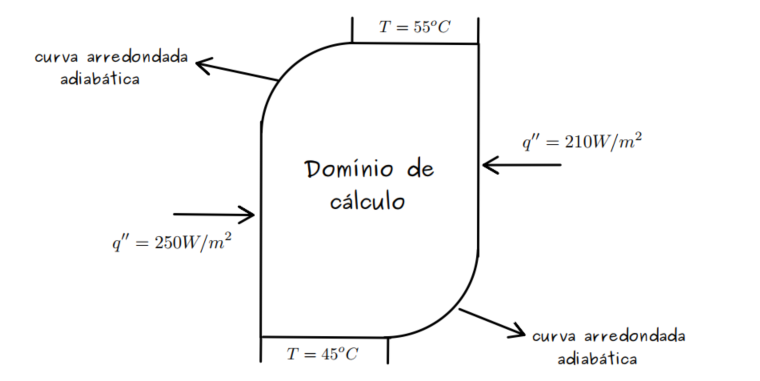


# Desenvolvimento das funções necessárias

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve

def gerar_malha_com_ajuste_local_e_mapa(Lx, Ly, nx, ny, raio=0.33, eps=1e-6):
    """
    Gera uma malha retangular com espaçamento uniforme, aplicando ajustes locais (fatores alfa e beta)
    nas regiões de contorno com curvatura convexa.

    Parâmetros:
    -----------
    Lx : float
        Largura do domínio [cm]
    Ly : float
        Altura do domínio [cm]
    nx : int
        Número de nós na direção x
    ny : int
        Número de nós na direção y
    raio : float, opcional
        Raio da curvatura convexa nas bordas (em cm)
    eps : float, opcional
        Tolerância numérica para evitar divisões por zero

    Retorna:
    --------
    X, Y : 2D arrays
        Coordenadas da malha
    mask : 2D bool array
        Máscara booleana indicando pontos dentro do domínio
    ALPHA, BETA : 2D arrays
        Fatores de ajuste local nas direções x (alfa) e y (beta)
    mapa : 2D int array
        Mapeamento dos nós internos para índices do sistema linear
    """
    dx = Lx / (nx - 1)
    dy = Ly / (ny - 1)
    x = np.linspace(0, Lx, nx)
    y = np.linspace(0, Ly, ny)
    X, Y = np.meshgrid(x, y)

    # Inicialização das máscaras e fatores
    mask = np.ones_like(X, dtype=bool)
    ALPHA = np.ones_like(X, dtype=float)
    BETA = np.ones_like(X, dtype=float)

    # Região com curvatura convexa superior esquerda
    centro_sup_esq = (raio, Ly - raio)
    dx_sup = np.abs(X - centro_sup_esq[0])
    dy_sup = np.abs(Y - centro_sup_esq[1])
    dist_sup = np.sqrt(dx_sup**2 + dy_sup**2)

    # Ponto fora do domínio
    fora_sup = (X < raio + eps) & (Y > Ly - raio - eps) & (dist_sup > raio + eps)
    mask[fora_sup] = False

    # Ajuste local nos pontos da borda da curva
    encostando_sup = (X < raio + eps) & (Y > Ly - raio - eps) & (np.abs(dist_sup - raio) <= max(dx, dy))
    ALPHA[encostando_sup] = np.clip(raio / (dx_sup[encostando_sup] + eps), 0, 1)
    BETA[encostando_sup] = np.clip(raio / (dy_sup[encostando_sup] + eps), 0, 1)

    # Região com curvatura convexa inferior direita
    centro_inf_dir = (Lx - raio, raio)
    dx_inf = np.abs(X - centro_inf_dir[0])
    dy_inf = np.abs(Y - centro_inf_dir[1])
    dist_inf = np.sqrt(dx_inf**2 + dy_inf**2)

    fora_inf = (X > Lx - raio - eps) & (Y < raio + eps) & (dist_inf > raio + eps)
    mask[fora_inf] = False

    encostando_inf = (X > Lx - raio - eps) & (Y < raio + eps) & (np.abs(dist_inf - raio) <= max(dx, dy))
    ALPHA[encostando_inf] = np.clip(raio / (dx_inf[encostando_inf] + eps), 0, 1)
    BETA[encostando_inf] = np.clip(raio / (dy_inf[encostando_inf] + eps), 0, 1)

    # Mapeamento dos pontos válidos para o sistema linear
    mapa = -1 * np.ones_like(X, dtype=int)
    idx = 0
    for j in range(ny):
        for i in range(nx):
            if mask[j, i]:
                mapa[j, i] = idx
                idx += 1

    return X, Y, mask, ALPHA, BETA, mapa

In [ ]:
def montar_sistema_laplace_com_cc(X, Y, mask, ALPHA, BETA, mapa, 
                                  k=1.0, q_esq=250, q_dir=210, T_sup=55, T_inf=45):
    """
    Monta o sistema linear A*T = b para a equação de Laplace com condições de contorno mistas:
    - Temperatura fixa (Dirichlet) nas bordas superior e inferior
    - Fluxo de calor (Neumann) nas bordas laterais
    - Ajustes locais via alfa e beta nas curvas convexas

    Parâmetros:
    -----------
    X, Y : 2D arrays
        Coordenadas da malha
    mask : 2D bool array
        Máscara indicando pontos válidos do domínio
    ALPHA, BETA : 2D arrays
        Fatores de correção do espaçamento (curvas)
    mapa : 2D int array
        Mapeamento de índices globais do sistema linear
    k : float, opcional
        Condutividade térmica
    q_esq, q_dir : float, opcionais
        Fluxo de calor nas bordas esquerda e direita
    T_sup, T_inf : float, opcionais
        Temperaturas fixas nas bordas superior e inferior

    Retorna:
    --------
    A : scipy.sparse.csr_matrix
        Matriz do sistema linear
    b : ndarray
        Vetor de termos independentes
    """
    ny, nx = X.shape
    N = np.max(mapa) + 1

    dx = X[0, 1] - X[0, 0]
    dy = Y[1, 0] - Y[0, 0]

    A = lil_matrix((N, N))
    b = np.zeros(N)

    for j in range(ny):
        for i in range(nx):
            if not mask[j, i]:
                continue

            p = mapa[j, i]
            alpha = ALPHA[j, i]
            beta = BETA[j, i]

            esquerda = (i == 0)
            direita = (i == nx - 1)
            inferior = (j == 0)
            superior = (j == ny - 1)

            # Condições de contorno de Dirichlet (T fixo)
            if inferior:
                A[p, p] = 1
                b[p] = T_inf
                continue
            elif superior:
                A[p, p] = 1
                b[p] = T_sup
                continue

            coef = {}

            # Vizinhos horizontais
            if i > 0 and mask[j, i - 1]:
                pk = mapa[j, i - 1]
                coef[pk] = 1 / (alpha * dx) ** 2
            elif esquerda:
                # Neumann não homogênea (fluxo à esquerda)
                b[p] -= -q_esq / k / (alpha * dx)

            if i < nx - 1 and mask[j, i + 1]:
                pk = mapa[j, i + 1]
                coef[pk] = 1 / (alpha * dx) ** 2
            elif direita:
                b[p] -= q_dir / k / (alpha * dx)

            # Vizinhos verticais
            if j > 0 and mask[j - 1, i]:
                pk = mapa[j - 1, i]
                coef[pk] = 1 / (beta * dy) ** 2

            if j < ny - 1 and mask[j + 1, i]:
                pk = mapa[j + 1, i]
                coef[pk] = 1 / (beta * dy) ** 2

            # Ponto central
            A[p, p] = -2 / (alpha * dx) ** 2 - 2 / (beta * dy) ** 2
            for pk, val in coef.items():
                A[p, pk] = val

    return A.tocsr(), b

# Resultado do estudo para resolução da equação de Laplace para a geometria proposta

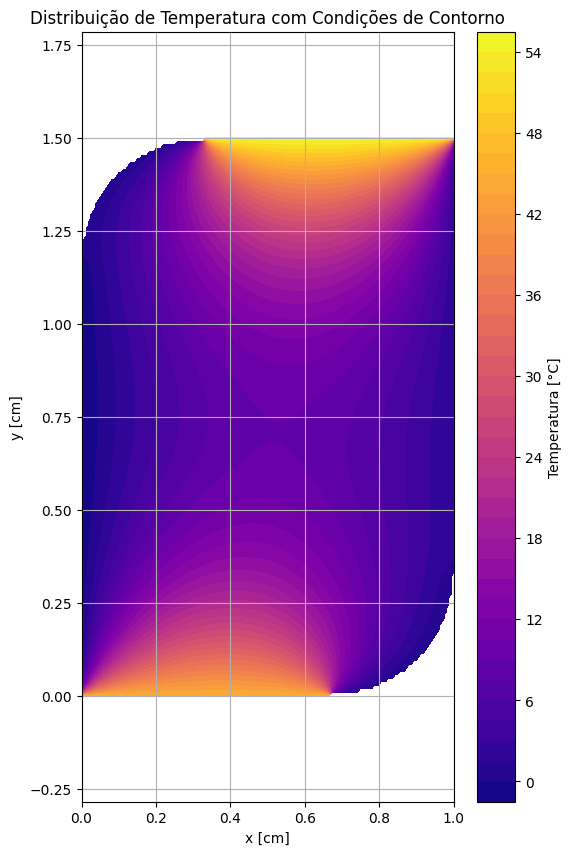

In [7]:
# Parâmetros
Lx, Ly = 1.0, 1.5
nx, ny = 160, 160

# Gerar malha
X, Y, mask, ALPHA, BETA, mapa = gerar_malha_com_ajuste_local_e_mapa(Lx, Ly, nx, ny)

# Montar sistema com CC
A_cc, b_cc = montar_sistema_laplace_com_cc(X, Y, mask, ALPHA, BETA, mapa)
T_flat_cc = spsolve(A_cc, b_cc)

# Reconstruir campo
T_cc = np.full_like(X, np.nan, dtype=float)
for j in range(ny):
    for i in range(nx):
        if mask[j, i]:
            T_cc[j, i] = T_flat_cc[mapa[j, i]]

# Visualização
plt.figure(figsize=(6, 10))
cp = plt.contourf(X, Y, T_cc, levels=50, cmap='plasma')
plt.colorbar(cp, label='Temperatura [°C]')
plt.title('Distribuição de Temperatura com Condições de Contorno')
plt.xlabel('x [cm]')
plt.ylabel('y [cm]')
plt.axis('equal')
plt.grid(True)
plt.show()